## Análise da Ortogonalidade do Modelo
Nesta etapa, extraímos os vetores $V_{piloto}$ e $V_{equipe}$ do conjunto de teste (2023) para comparar o modelo com e sem a restrição de ortogonalidade.

A validação agora separa duas leituras distintas:
1. **Métrica alinhada ao treino**: média de $|\cos(V_{piloto}^{(n)}, V_{equipe}^{(n)})|$ por amostra (mesma ideia da `OrthogonalSeparationLoss`).
2. **Métrica estrutural complementar**: matriz dimensão-a-dimensão (8x8) no conjunto de teste, para inspeção de acoplamento linear entre coordenadas latentes.

Assim, o heatmap não é tratado como prova direta da mesma ortogonalidade otimizada na loss, e sim como diagnóstico adicional.

In [1]:
import sys
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("src"))

from train import prepare_data_and_graph
from models.pipeline_fusion import F1OrthogonalPipeline

# 1. Carregar os dados
_, _, test_loader, graph_data = prepare_data_and_graph()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
graph_data = graph_data.to(device)


def load_model_config(model_name):
    """Lê lambda_orthogonal do arquivo de resultados para rotular os gráficos."""
    with open("output/models/training_results.json", "r") as f:
        results = json.load(f)

    for result in results:
        if result["model_name"] == model_name:
            return result["configuration"]

    raise ValueError(f"Modelo '{model_name}' não encontrado em training_results.json")


# 2. Função para extrair vetores do modelo
def get_vectors(model_name, latent_dim=8, use_track_encoder=True):
    num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}
    model = F1OrthogonalPipeline(
        num_nodes_dict=num_nodes_dict,
        latent_dim=latent_dim,
        use_track_encoder=use_track_encoder,
    ).to(device)
    model.load_state_dict(torch.load(f"output/models/{model_name}.pth", map_location=device))
    model.eval()

    all_v_piloto = []
    all_v_equipe = []

    with torch.no_grad():
        for batch in test_loader:
            x_driver, x_track, target_constructor_ids, _ = [b.to(device) for b in batch]
            _, _, _, v_piloto, v_equipe = model(
                x_driver=x_driver,
                x_track=x_track,
                graph_x_dict=graph_data.x_dict,
                graph_edge_index_dict=graph_data.edge_index_dict,
                target_constructor_ids=target_constructor_ids,
            )
            all_v_piloto.append(v_piloto.cpu())
            all_v_equipe.append(v_equipe.cpu())

    v_piloto_tensor = torch.cat(all_v_piloto, dim=0)  # (N, 8)
    v_equipe_tensor = torch.cat(all_v_equipe, dim=0)  # (N, 8)
    return v_piloto_tensor, v_equipe_tensor


# 3. Métrica alinhada ao treino (igual à ideia da OrthogonalSeparationLoss)
def pairwise_abs_cosine_stats(v_p_tensor, v_e_tensor):
    v_p_norm = F.normalize(v_p_tensor, p=2, dim=-1)
    v_e_norm = F.normalize(v_e_tensor, p=2, dim=-1)

    abs_cos = torch.abs(torch.sum(v_p_norm * v_e_norm, dim=-1))

    stats = {
        "mean_abs_cos": abs_cos.mean().item(),
        "median_abs_cos": abs_cos.median().item(),
        "p95_abs_cos": torch.quantile(abs_cos, q=0.95).item(),
        "pct_abs_cos_lt_01": (abs_cos < 0.1).float().mean().item() * 100.0,
    }
    return stats, abs_cos.numpy()


# 4. Métrica estrutural complementar (dimensão x dimensão no dataset)
def calc_cross_dim_matrix(v_p_tensor, v_e_tensor):
    """
    Matriz 8x8 de acoplamento linear entre dimensões:
    - centraliza cada dimensão no dataset
    - normaliza por desvio padrão
    - calcula correlação cruzada entre V_piloto e V_equipe
    """
    eps = 1e-8

    v_p_center = v_p_tensor - v_p_tensor.mean(dim=0, keepdim=True)
    v_e_center = v_e_tensor - v_e_tensor.mean(dim=0, keepdim=True)

    v_p_std = v_p_center / (v_p_center.std(dim=0, keepdim=True) + eps)
    v_e_std = v_e_center / (v_e_center.std(dim=0, keepdim=True) + eps)

    n = v_p_std.shape[0]
    cross_corr = torch.matmul(v_p_std.T, v_e_std) / max(n - 1, 1)
    return torch.abs(cross_corr).numpy()


print("Extraindo vetores...")
config_orth = load_model_config("model_orthogonal")
config_no_orth = load_model_config("model_no_orthogonal")

v_piloto_orth, v_equipe_orth = get_vectors("model_orthogonal")
v_piloto_no_orth, v_equipe_no_orth = get_vectors("model_no_orthogonal")

print("Calculando métricas de ortogonalidade alinhadas ao treino...")
stats_orth, abs_cos_orth = pairwise_abs_cosine_stats(v_piloto_orth, v_equipe_orth)
stats_no_orth, abs_cos_no_orth = pairwise_abs_cosine_stats(v_piloto_no_orth, v_equipe_no_orth)

print("\n=== Métrica alinhada ao treino em 2023 (menor é melhor) ===")
print(
    f"Com ortogonalidade (lambda={config_orth['lambda_orthogonal']}): "
    f"mean={stats_orth['mean_abs_cos']:.4f}, "
    f"median={stats_orth['median_abs_cos']:.4f}, "
    f"p95={stats_orth['p95_abs_cos']:.4f}, "
    f"%(|cos|<0.1)={stats_orth['pct_abs_cos_lt_01']:.1f}%"
)
print(
    f"Sem ortogonalidade (lambda={config_no_orth['lambda_orthogonal']}): "
    f"mean={stats_no_orth['mean_abs_cos']:.4f}, "
    f"median={stats_no_orth['median_abs_cos']:.4f}, "
    f"p95={stats_no_orth['p95_abs_cos']:.4f}, "
    f"%(|cos|<0.1)={stats_no_orth['pct_abs_cos_lt_01']:.1f}%"
)

print("\nCalculando matriz estrutural complementar dimensão-a-dimensão...")
sim_orth = calc_cross_dim_matrix(v_piloto_orth, v_equipe_orth)
sim_no_orth = calc_cross_dim_matrix(v_piloto_no_orth, v_equipe_no_orth)

# 5. Heatmaps complementares (não equivalem diretamente à loss de treino)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(sim_orth, ax=axes[0], cmap="Reds", vmin=0, vmax=1)
axes[0].set_title(
    f"Com Ortogonalidade (lambda={config_orth['lambda_orthogonal']})\n"
    "Matriz estrutural complementar |corr| (dim x dim)"
)
axes[0].set_xlabel("Dimensões V_equipe")
axes[0].set_ylabel("Dimensões V_piloto")

sns.heatmap(sim_no_orth, ax=axes[1], cmap="Reds", vmin=0, vmax=1)
axes[1].set_title(
    f"Sem Ortogonalidade (lambda={config_no_orth['lambda_orthogonal']})\n"
    "Matriz estrutural complementar |corr| (dim x dim)"
)
axes[1].set_xlabel("Dimensões V_equipe")
axes[1].set_ylabel("Dimensões V_piloto")

plt.tight_layout()
plt.show()

# 6. Distribuição da métrica alinhada ao treino
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(abs_cos_orth, bins=30, alpha=0.65, label="Com ortogonalidade", density=True)
ax.hist(abs_cos_no_orth, bins=30, alpha=0.50, label="Sem ortogonalidade", density=True)
ax.set_title("Distribuição de |cos(V_piloto, V_equipe)| por amostra (2023)")
ax.set_xlabel("|cos| por instância")
ax.set_ylabel("Densidade")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

ModuleNotFoundError: No module named 'torch'

## Atribuição de Crédito de Shapley: O Duelo de 2021

-> Carregando Grafo do RelBench...
-> Carregando e Alinhando CSV Tabular...
-> Train: 1608, Val: 438, Test: 238
Carregando modelo (Excluir Pista: False)...


100%|██████████| 2/2 [00:00<00:00,  5.47it/s]



 RESULTADO SHAP: GP DE ABU DHABI 2021
MAX VERSTAPPEN : Piloto 53.7% | Equipe 46.3% | Pista 0.0%
LEWIS HAMILTON : Piloto 28.2% | Equipe 71.8% | Pista 0.0%


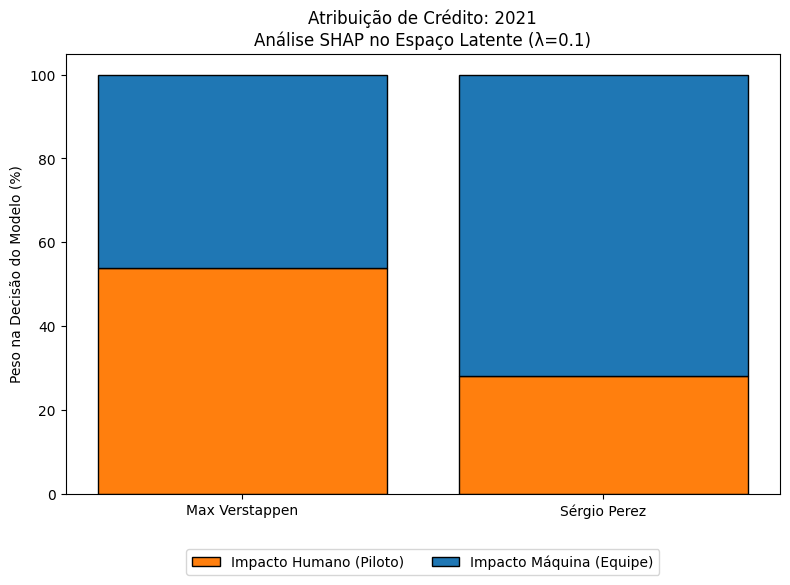

In [3]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DA FLAG ---
EXCLUDE_TRACK_ENCODER = False # Alterne aqui conforme necessário
# ---------------------------

sys.path.append(os.path.abspath("src"))
from train import prepare_data_and_graph
from models.pipeline_fusion import F1OrthogonalPipeline

# 1. Configurações Iniciais
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_, _, test_loader, graph_data = prepare_data_and_graph()
graph_data = graph_data.to(device)

print(f"Carregando modelo (Excluir Pista: {EXCLUDE_TRACK_ENCODER})...")
num_nodes_dict = {nt: graph_data[nt].num_nodes for nt in graph_data.node_types}
model = F1OrthogonalPipeline(num_nodes_dict=num_nodes_dict, latent_dim=8).to(device)
model.load_state_dict(torch.load("output/models/model_orthogonal.pth", map_location=device))
model.eval()

# 2. Busca de dados e Tensores
RACE_YEAR = 2021
RACE_ROUND = 5
DRIVER_MAX_ID = 829 
DRIVER_LEWIS_ID = 3

df_instances = pd.read_csv("output/dataset/instances.csv")
abu_dhabi_df = df_instances[(df_instances['year'] == RACE_YEAR) & (df_instances['round'] == RACE_ROUND)]
max_row = abu_dhabi_df[abu_dhabi_df['driverId'] == DRIVER_MAX_ID].iloc[0]
lewis_row = abu_dhabi_df[abu_dhabi_df['driverId'] == DRIVER_LEWIS_ID].iloc[0]

driver_features = ['avg_qualifying_pos', 'teammate_delta', 'crash_rate', 'podium_rate', 'experience', 'points_per_finish']
track_features = ['altitude_m', 'length_m', 'corners_count', 'rotation', 'avg_track_temp']

def get_instance_tensors(row):
    x_d = torch.tensor(row[driver_features].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    x_t = torch.tensor(row[track_features].astype(float).values, dtype=torch.float32).unsqueeze(0).to(device)
    c_id = torch.tensor([int(row['constructorId'])], dtype=torch.long).to(device)
    return x_d, x_t, c_id

max_x_d, max_x_t, max_c_id = get_instance_tensors(max_row)
lewis_x_d, lewis_x_t, lewis_c_id = get_instance_tensors(lewis_row)

# 3. Extração Dinâmica
def get_fused_vector(x_d, x_t, c_id):
    with torch.no_grad():
        v_piloto = model.driver_encoder(x_d)
        v_equipe = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_id)
        
        if EXCLUDE_TRACK_ENCODER:
            return torch.cat([v_piloto, v_equipe], dim=-1) # (1, 16)
        else:
            v_pista = model.track_encoder(x_t)
            return torch.cat([v_piloto, v_equipe, v_pista], dim=-1) # (1, 24)

max_fused = get_fused_vector(max_x_d, max_x_t, max_c_id)
lewis_fused = get_fused_vector(lewis_x_d, lewis_x_t, lewis_c_id)
X_eval = torch.cat([max_fused, lewis_fused], dim=0)

# 4. Cálculo SHAP Dinâmico (Fundo Realista)
background_list = []
with torch.no_grad():
    for batch in test_loader:
        x_d, x_t, c_ids, _ = [b.to(device) for b in batch]
        v_p = model.driver_encoder(x_d)
        v_e = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_ids)
        if EXCLUDE_TRACK_ENCODER:
            v_f = torch.cat([v_p, v_e], dim=-1)
        else:
            v_t = model.track_encoder(x_t)
            v_f = torch.cat([v_p, v_e, v_t], dim=-1)
        background_list.append(v_f.cpu().numpy())
        if sum(len(b) for b in background_list) >= 50:
            break
background_np = np.concatenate(background_list, axis=0)[:50]
explainer = shap.KernelExplainer(
    lambda x: model.classifier(torch.tensor(x, dtype=torch.float32).to(device)).sigmoid().detach().cpu().numpy(), 
    background_np
)
shap_vals = explainer.shap_values(X_eval.cpu().numpy())
background_list = []
with torch.no_grad():
    for batch in test_loader:
        x_d, x_t, c_ids, _ = [b.to(device) for b in batch]
        v_p = model.driver_encoder(x_d)
        v_e = model.team_encoder(graph_data.x_dict, graph_data.edge_index_dict, c_ids)
        if EXCLUDE_TRACK_ENCODER:
            v_f = torch.cat([v_p, v_e], dim=-1)
        else:
            v_t = model.track_encoder(x_t)
            v_f = torch.cat([v_p, v_e, v_t], dim=-1)
        background_list.append(v_f.cpu().numpy())
        if sum(len(b) for b in background_list) >= 50:
            break
background_np = np.concatenate(background_list, axis=0)[:50]

# 5. Agregação Dinâmica
def summarize_blocks(shap_array):
    abs_shap = np.abs(shap_array)
    impact_piloto = np.sum(abs_shap[0:8])
    impact_equipe = np.sum(abs_shap[8:16])
    if not EXCLUDE_TRACK_ENCODER:
        impact_pista = np.sum(abs_shap[16:24])
        total = impact_piloto + impact_equipe + impact_pista
        return (impact_piloto/total)*100, (impact_equipe/total)*100, (impact_pista/total)*100
    else:
        total = impact_piloto + impact_equipe
        return (impact_piloto/total)*100, (impact_equipe/total)*100, 0.0

max_impact = summarize_blocks(shap_vals[0])
lewis_impact = summarize_blocks(shap_vals[1])

print("\n" + "="*50)
print(" RESULTADO SHAP: GP DE ABU DHABI 2021")
print("="*50)
print(f"MAX VERSTAPPEN : Piloto {max_impact[0]:.1f}% | Equipe {max_impact[1]:.1f}% | Pista {max_impact[2]:.1f}%")
print(f"LEWIS HAMILTON : Piloto {lewis_impact[0]:.1f}% | Equipe {lewis_impact[1]:.1f}% | Pista {lewis_impact[2]:.1f}%")

# Gráfico
labels = ['Max Verstappen', 'Sérgio Perez']
piloto_vals = [max_impact[0], lewis_impact[0]]
equipe_vals = [max_impact[1], lewis_impact[1]]

plt.figure(figsize=(8, 6))
plt.bar(labels, piloto_vals, label='Impacto Humano (Piloto)', color='#ff7f0e', edgecolor='black')
plt.bar(labels, equipe_vals, bottom=piloto_vals, label='Impacto Máquina (Equipe)', color='#1f77b4', edgecolor='black')
plt.ylabel("Peso na Decisão do Modelo (%)")
plt.title("Atribuição de Crédito: 2021\nAnálise SHAP no Espaço Latente (λ=0.1)")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.show()

## Mundos Paralelos - Transferência de Pilotos